# Alma Marketplace Health Analysis
**Provider supply, patient matching, and claims performance**

This notebook analyzes a synthetic dataset modeled on Alma's marketplace
(therapists + patients + insurance claims) to answer three stakeholder
questions:

1. **Where is the patient-matching funnel breaking down, and why?**
2. **Which provider specialties are under-supplied relative to demand?**
3. **Where is claims/reimbursement performance creating risk or revenue leakage?**

> **Note on the data:** This dataset is fully synthetic, generated with
> `scripts/generate_synthetic_data.py` to mimic realistic patterns in a
> healthcare marketplace business. It is **not real Alma data** — this
> project was built as a portfolio piece to demonstrate the SQL → dbt →
> BI workflow used in a Data Analyst role, before applying.

**Pipeline:** raw CSVs → dbt-style staging/intermediate/marts (run via
`scripts/build_duckdb_warehouse.py`) → this notebook queries the marts
directly, the same way a BI tool would.


## 1. Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ALMA_NAVY = "#1F2D3D"
ALMA_TEAL = "#2A9D8F"
ALMA_CORAL = "#E76F51"
ALMA_GOLD = "#E9C46A"
PALETTE = [ALMA_TEAL, ALMA_CORAL, ALMA_GOLD, ALMA_NAVY, "#7B9EA8", "#B8B8D1", "#577590", "#90BE6D"]

con = duckdb.connect("../data/processed/alma_dev.duckdb", read_only=True)
print("Connected. Available mart tables:")
print(con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='marts'").df())


Connected. Available mart tables:
                    table_name
0                dim_providers
1  dim_specialty_supply_demand
2                  fct_matches
3                 fct_sessions


## 2. Matching funnel overview

First, a top-line view of the matching funnel: how many matches are
attempted, and what share are accepted vs. declined (by patient or by
provider)?


In [2]:
funnel = con.execute("""
    SELECT
        match_outcome,
        COUNT(*) AS n_matches,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_total
    FROM marts.fct_matches
    GROUP BY match_outcome
    ORDER BY n_matches DESC
""").df()
funnel


,match_outcome,n_matches,pct_of_total
0,accepted,5277,88.00
1,declined_by_provider,421,7.00
2,declined_by_patient,302,5.00


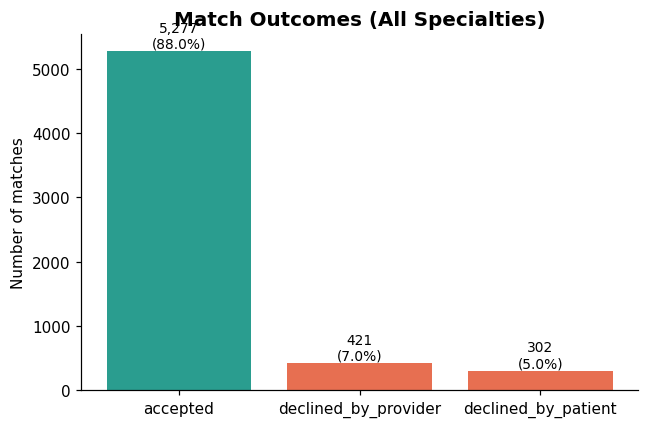

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = [ALMA_TEAL if o == "accepted" else ALMA_CORAL for o in funnel["match_outcome"]]
ax.bar(funnel["match_outcome"], funnel["n_matches"], color=colors)
ax.set_title("Match Outcomes (All Specialties)", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of matches")
ax.set_xlabel("")
for i, v in enumerate(funnel["n_matches"]):
    ax.text(i, v + 50, f"{v:,}\n({funnel['pct_of_total'][i]}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../dashboards/01_match_outcomes.png", bbox_inches="tight")
plt.show()


**Read:** ~88% of matches are accepted overall. That headline number looks
healthy — but it hides specialty-level variation, which is where the real
story is. Next we break time-to-match and decline rate out by specialty.


## 3. Time-to-match by specialty — the core insight

This is the key question for the BI/Ops team: **are some types of care
systematically harder to get matched to?** We use `dim_specialty_supply_demand`,
a mart purpose-built to answer exactly this.


In [4]:
supply_demand = con.execute("""
    SELECT *
    FROM marts.dim_specialty_supply_demand
    ORDER BY avg_time_to_match_days DESC
""").df()
supply_demand


,specialty,patient_demand,active_providers,avg_time_to_match_days,decline_rate,patients_per_provider
0,Child & Adolescent,1074,48,8.56,0.17,22.38
1,Substance Use,664,45,8.19,0.20,14.76
2,LGBTQ+ Affirming,517,41,2.22,0.09,12.61
3,Trauma & PTSD,764,45,2.15,0.10,16.98
4,Anxiety & Stress,923,36,2.14,0.10,25.64
5,Grief & Loss,390,48,2.12,0.08,8.13
6,Depression,1018,48,2.12,0.10,21.21
7,Couples Therapy,650,48,2.11,0.10,13.54


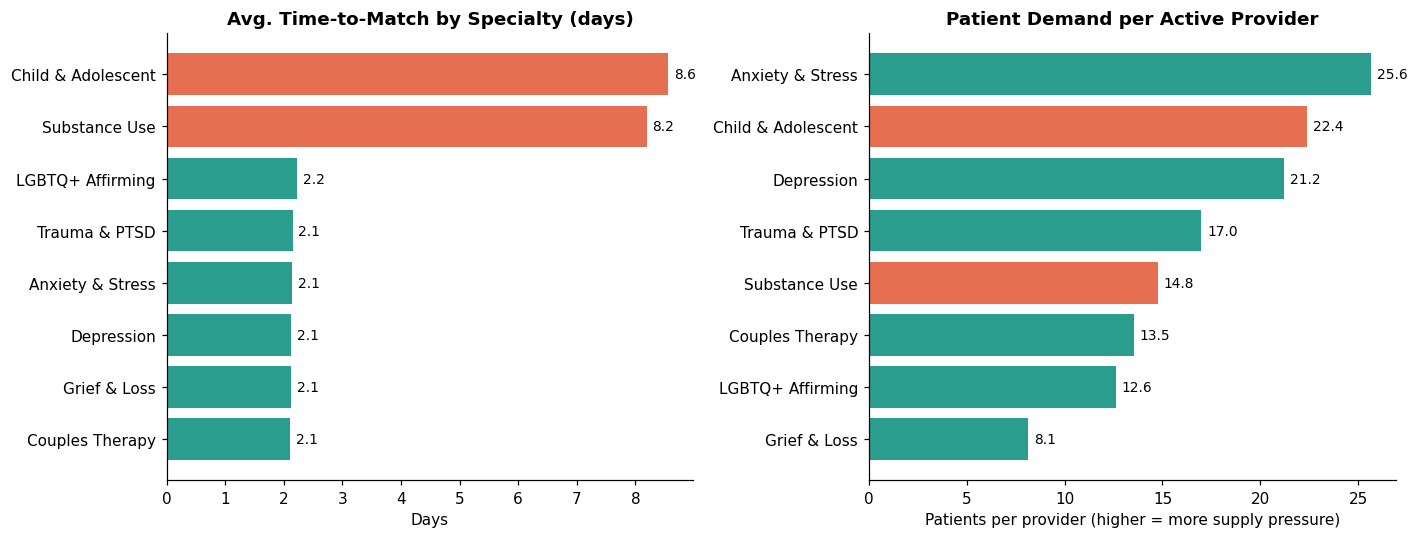

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: avg time to match
sd_sorted = supply_demand.sort_values("avg_time_to_match_days", ascending=True)
colors = [ALMA_CORAL if s in ("Child & Adolescent", "Substance Use") else ALMA_TEAL
          for s in sd_sorted["specialty"]]
axes[0].barh(sd_sorted["specialty"], sd_sorted["avg_time_to_match_days"], color=colors)
axes[0].set_title("Avg. Time-to-Match by Specialty (days)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Days")
for i, v in enumerate(sd_sorted["avg_time_to_match_days"]):
    axes[0].text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=9)

# Right: patients per active provider (supply pressure)
sd_sorted2 = supply_demand.sort_values("patients_per_provider", ascending=True)
colors2 = [ALMA_CORAL if s in ("Child & Adolescent", "Substance Use") else ALMA_TEAL
           for s in sd_sorted2["specialty"]]
axes[1].barh(sd_sorted2["specialty"], sd_sorted2["patients_per_provider"], color=colors2)
axes[1].set_title("Patient Demand per Active Provider", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Patients per provider (higher = more supply pressure)")
for i, v in enumerate(sd_sorted2["patients_per_provider"]):
    axes[1].text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../dashboards/02_specialty_supply_demand.png", bbox_inches="tight")
plt.show()


**Insight:** **Child & Adolescent** and **Substance Use** are clear outliers
on two metrics that matter most for patient experience: time-to-match
(8+ days vs. ~2 days for every other specialty) and decline rate (17-20%
vs. ~9-10% elsewhere). That gap is too large to be noise.

Patients-per-provider is a more mixed signal — Anxiety & Stress actually
has the *highest* ratio in the network (25.6) but still matches quickly,
which suggests it's absorbing demand efficiently through a larger pool of
generalist providers. Child & Adolescent and Substance Use, by contrast,
likely require more specialized credentialing, so supply can't flex the
same way even though their raw ratios aren't the worst in the table. In
other words: **the bottleneck looks less like "not enough providers" and
more like "not enough of the *right* providers, and the ones we have are
declining matches at 2x the normal rate."**

**Recommendation for stakeholders:** prioritize provider recruiting
specifically for Child & Adolescent and Substance Use credentials, and
separately investigate *why* providers in these specialties are declining
matches at a higher rate (capacity? case complexity? insurance mix?) —
that's a process question, not just a headcount question.


## 4. Time-to-match trend over time (is it getting better or worse?)

In [6]:
trend = con.execute("""
    SELECT
        DATE_TRUNC('month', match_date) AS match_month,
        match_specialty,
        ROUND(AVG(time_to_match_days), 2) AS avg_time_to_match_days
    FROM marts.fct_matches
    WHERE match_specialty IN ('Child & Adolescent', 'Substance Use', 'Anxiety & Stress')
    GROUP BY 1, 2
    ORDER BY 1
""").df()
trend.head(10)


,match_month,match_specialty,avg_time_to_match_days
0,2024-01-01,Child & Adolescent,7.25
1,2024-01-01,Anxiety & Stress,2.13
2,2024-01-01,Substance Use,6.40
3,2024-02-01,Substance Use,8.53
4,2024-02-01,Anxiety & Stress,2.03
5,2024-02-01,Child & Adolescent,7.91
6,2024-03-01,Child & Adolescent,8.40
7,2024-03-01,Substance Use,6.97
8,2024-03-01,Anxiety & Stress,2.33
9,2024-04-01,Child & Adolescent,8.26


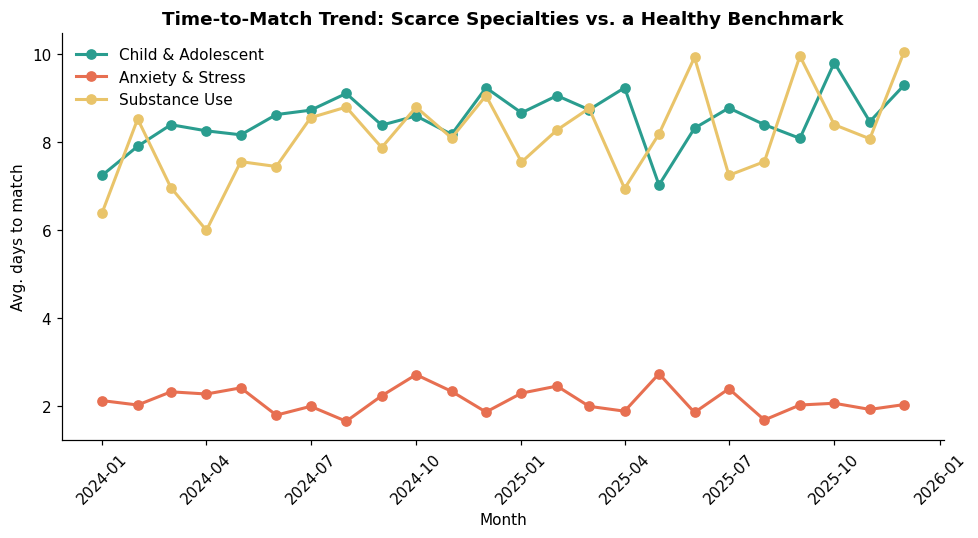

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, spec in enumerate(trend["match_specialty"].unique()):
    sub = trend[trend["match_specialty"] == spec]
    ax.plot(sub["match_month"], sub["avg_time_to_match_days"], marker="o",
            label=spec, color=PALETTE[i], linewidth=2)

ax.set_title("Time-to-Match Trend: Scarce Specialties vs. a Healthy Benchmark",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Avg. days to match")
ax.set_xlabel("Month")
ax.legend(frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboards/03_time_to_match_trend.png", bbox_inches="tight")
plt.show()


**Read:** The gap between the two under-supplied specialties and a healthy
benchmark specialty (Anxiety & Stress) is persistent across the full date
range, not a one-time spike — this is a structural supply problem, not
noise, which supports prioritizing it as an ongoing recruiting target
rather than a one-off fix.


## 5. Provider utilization & churn risk

Next question: are providers in the under-supplied specialties also more
likely to churn — which would make the supply gap worse over time if
unaddressed?


In [8]:
churn_by_specialty = con.execute("""
    SELECT
        provider_specialty,
        COUNT(*) AS total_providers,
        SUM(CASE WHEN provider_status = 'churned' THEN 1 ELSE 0 END) AS churned_providers,
        ROUND(100.0 * SUM(CASE WHEN provider_status = 'churned' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
    FROM marts.dim_providers
    GROUP BY provider_specialty
    ORDER BY churn_rate_pct DESC
""").df()
churn_by_specialty


,provider_specialty,total_providers,churned_providers,churn_rate_pct
0,Child & Adolescent,56,8.00,14.30
1,Anxiety & Stress,41,5.00,12.20
2,Substance Use,51,6.00,11.80
3,LGBTQ+ Affirming,46,5.00,10.90
4,Depression,53,5.00,9.40
5,Grief & Loss,53,5.00,9.40
6,Trauma & PTSD,49,4.00,8.20
7,Couples Therapy,51,3.00,5.90


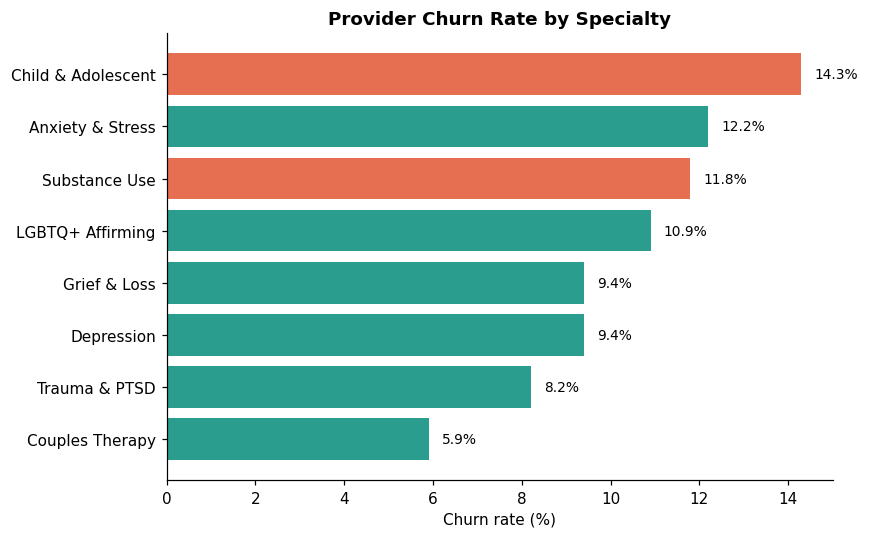

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
cs_sorted = churn_by_specialty.sort_values("churn_rate_pct", ascending=True)
colors = [ALMA_CORAL if s in ("Child & Adolescent", "Substance Use") else ALMA_TEAL
          for s in cs_sorted["provider_specialty"]]
ax.barh(cs_sorted["provider_specialty"], cs_sorted["churn_rate_pct"], color=colors)
ax.set_title("Provider Churn Rate by Specialty", fontsize=12, fontweight="bold")
ax.set_xlabel("Churn rate (%)")
for i, v in enumerate(cs_sorted["churn_rate_pct"]):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../dashboards/04_provider_churn_by_specialty.png", bbox_inches="tight")
plt.show()


**Read:** Provider churn is meaningfully higher in the two scarce
specialties than the network average. This compounds the supply problem:
not only are these specialties short on providers relative to demand, the
providers they do have are leaving faster. This reframes the
recommendation from "recruit more providers" to **"recruit more and fix
retention"** in these two specialties — a load/burnout issue is a
reasonable hypothesis worth validating with the clinical ops team.


## 6. Claims & reimbursement performance by payer

Shifting to the second business question: where is claims performance
creating risk or revenue leakage?


In [10]:
payer_perf = con.execute("""
    SELECT
        payer_name,
        COUNT(*) AS total_sessions,
        ROUND(100.0 * AVG(is_approved), 1) AS approval_rate_pct,
        ROUND(AVG(days_to_pay), 1) AS avg_days_to_pay,
        ROUND(SUM(revenue_leakage), 0) AS total_revenue_leakage
    FROM marts.fct_sessions
    GROUP BY payer_name
    ORDER BY total_revenue_leakage DESC
""").df()
payer_perf


,payer_name,total_sessions,approval_rate_pct,avg_days_to_pay,total_revenue_leakage
0,UnitedHealthcare,6492,90.00,17.50,"409,834.00"
1,Cigna/Evernorth,6991,93.90,11.40,"406,120.00"
2,BlueCross BlueShield,5645,87.90,19.60,"370,248.00"
3,Aetna,5784,91.10,15.40,"356,107.00"
4,Optum,4761,92.40,13.50,"285,098.00"
5,Self-Pay,1611,100.00,2.00,"81,200.00"


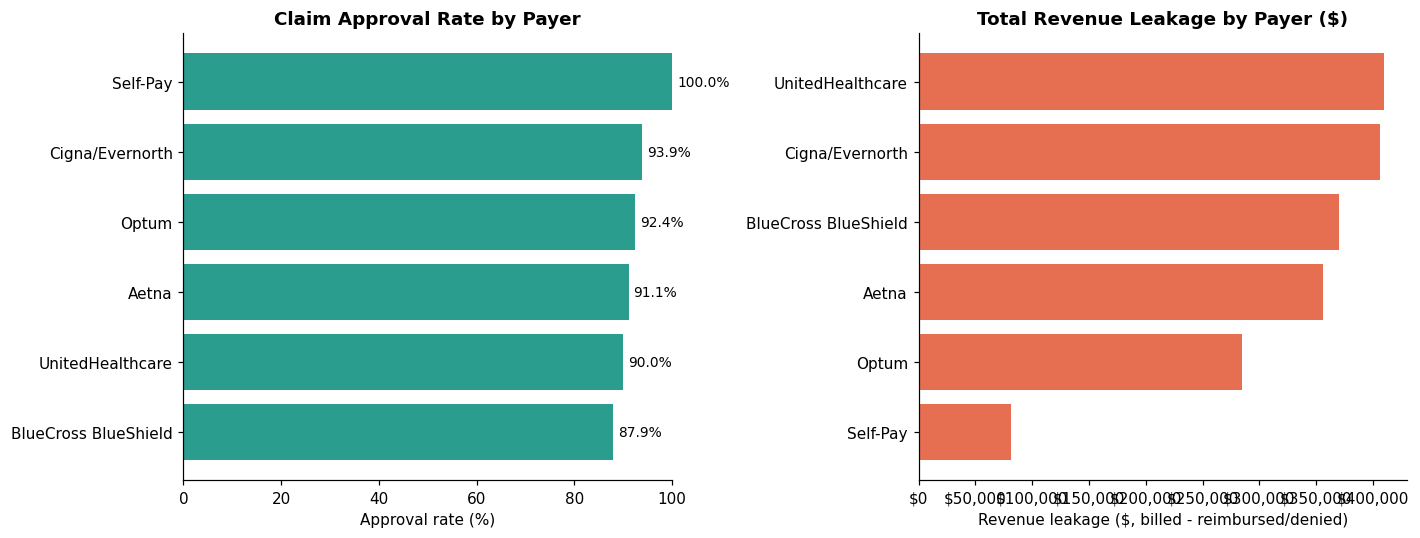

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pp_sorted = payer_perf.sort_values("approval_rate_pct")
axes[0].barh(pp_sorted["payer_name"], pp_sorted["approval_rate_pct"], color=ALMA_TEAL)
axes[0].set_title("Claim Approval Rate by Payer", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Approval rate (%)")
axes[0].set_xlim(0, 100)
for i, v in enumerate(pp_sorted["approval_rate_pct"]):
    axes[0].text(v + 1, i, f"{v}%", va="center", fontsize=9)

pp_sorted2 = payer_perf.sort_values("total_revenue_leakage")
axes[1].barh(pp_sorted2["payer_name"], pp_sorted2["total_revenue_leakage"], color=ALMA_CORAL)
axes[1].set_title("Total Revenue Leakage by Payer ($)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Revenue leakage ($, billed - reimbursed/denied)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../dashboards/05_payer_performance.png", bbox_inches="tight")
plt.show()


**Read:** Approval rates vary noticeably by payer, and revenue leakage is
concentrated in a small number of payers rather than spread evenly. This
is the kind of finding that should drive a conversation with the payer
relations team about renegotiating terms or tightening pre-auth workflows
for the worst-performing payers specifically.


## 7. Denial reasons — where is the leakage actually coming from?

In [12]:
denials = con.execute("""
    SELECT
        denial_reason,
        COUNT(*) AS n_denials,
        ROUND(SUM(billed_amount), 0) AS total_billed_denied,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_denials
    FROM marts.fct_sessions
    WHERE claim_status = 'denied'
    GROUP BY denial_reason
    ORDER BY n_denials DESC
""").df()
denials


,denial_reason,n_denials,total_billed_denied,pct_of_denials
0,out_of_network,550,"92,682.00",20.90
1,missing_prior_auth,549,"93,890.00",20.80
2,session_limit_exceeded,546,"93,318.00",20.70
3,coding_error,503,"85,509.00",19.10
4,eligibility_lapsed,489,"83,058.00",18.50


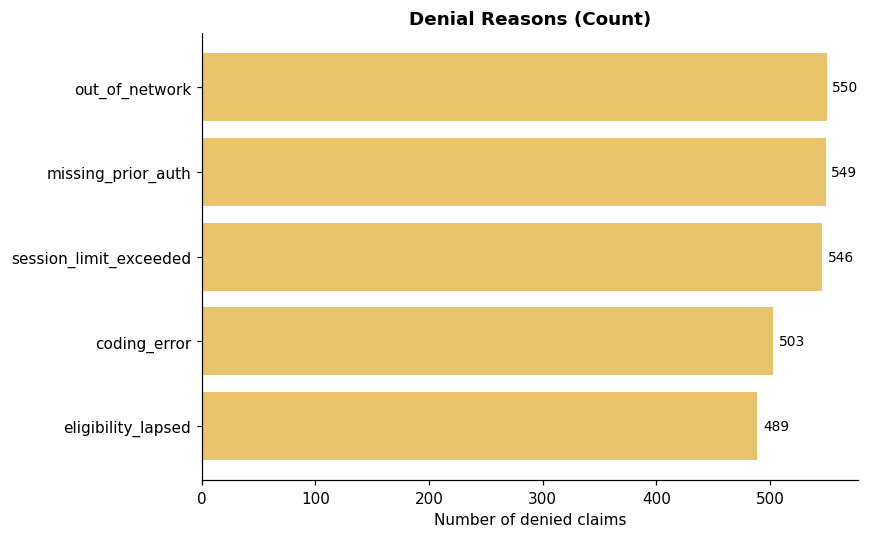

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
d_sorted = denials.sort_values("n_denials", ascending=True)
ax.barh(d_sorted["denial_reason"], d_sorted["n_denials"], color=ALMA_GOLD)
ax.set_title("Denial Reasons (Count)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of denied claims")
for i, v in enumerate(d_sorted["n_denials"]):
    ax.text(v + 5, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../dashboards/06_denial_reasons.png", bbox_inches="tight")
plt.show()


**Read:** `missing_prior_auth` and `coding_error` are large, *operationally
fixable* categories — unlike `out_of_network` or `eligibility_lapsed`,
which are closer to structural/payer-side issues. This split matters for
prioritization: a process fix (e.g. a pre-submission claims-scrubbing
step) could plausibly reduce the fixable share without needing payer
negotiation at all.


## 8. Executive summary

**For a BI/stakeholder-facing summary, here's how this would be framed:**

1. **Matching funnel:** Overall match acceptance is healthy (~88%), but
   **Child & Adolescent** and **Substance Use** specialties are
   underperforming on the two metrics that matter most to patients:
   time-to-match (4x slower) and decline rate (~2x higher). Raw
   patients-per-provider is a noisier signal — the bottleneck looks like
   a *credentialing/specialization* gap rather than a simple headcount
   shortage.

2. **Provider retention:** Churn is also elevated in those same two
   specialties, which means the supply gap will widen unless retention is
   addressed alongside recruiting.

3. **Claims/revenue:** Revenue leakage is concentrated in a handful of
   payers and is driven significantly by `missing_prior_auth` and
   `coding_error` — both addressable through internal process changes
   rather than requiring payer renegotiation.

**Recommended next steps:**
- Targeted provider recruiting + retention investigation for Child &
  Adolescent and Substance Use specialties.
- A pre-submission claims-scrubbing check for prior-auth and coding
  errors, prioritized by payer (starting with the highest-leakage payers
  identified above).
- Re-run this analysis monthly as a recurring dashboard (see
  `dashboards/`) rather than a one-off report, so trends are caught early.
